# Function 2

<b> Description of the Sample Application:</b> Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 
To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks


## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 28/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Added Week 2 output.<br>2. Added Week 2 feedback data point.<br>3. Replaced manual grid-search acquisition optimisation with a consolidated, reusable 'bayesian_optimization_step()' function.<br>5. Lowered β further (2.0 → 1.5), continuing the gradual exploration:exploitation shift.|
| 13/08/2026 | Week 4 | 1. Amended Week 3 input and output data points.<br>2. Re-tuned GP kernel: refit with widened length-scale bounds and compared log-marginal-likelihood against the original bounds, since earlier weeks repeatedly hit the upper length-scale bound (convergence warning).<br>3. Compared candidate peak regions found so far (checked whether the good points cluster around one region or suggest multiple local optima).<br>4. Continued lowering β (1.5 → 1.2). || 20/08/2026 | **Week 5** | 1. Amended Week 4 input and output data points.<br>2. Ran a plateau check: best-value-found has been flat for 4 consecutive weeks.<br>3. Re-examined the fitted noise level across weeks (found it has grown substantially, weakening confidence that the x1≈0.7 corridor is definitively 'the' peak vs. partly noise).<br>4. Ran an under-sampled-region check and found the low-x1/high-x2 quadrant is by far the least explored area of the domain.<br>5. Checked the naive next global suggestion against Week 4's already-submitted point and found them nearly identical (distance ≈ 0.05) - low marginal information.<br>6. **Strategy change:** based on 3-6, deliberately reversed course - raised β back up (1.2 → 1.8) and restricted this week's search to the identified under-sampled quadrant, instead of continuing to lower β and exploit the same corridor. |


# Weekly Progress Log

| Week | Query Submitted (x1-x2) | Output (y) | Acquisition | β (beta) | Kernel | Notes |
|---|---|---|---|---|---|---|
| Week 1 | 0.725451-0.000000 | 0.594526 | UCB | 2.5 | RBF | First submission-exploration-heavy (edge of domain, x2 = 0) |
| Week 2 | 0.959920-0.959920 | -0.053255 | UCB | 2.0 | RBF | Exploring the opposite corner (x1 ≈ x2 ≈ 0.96); output far lower than the GP's predicted mean (μ ≈ 0.39), which is a strong signal the RBF surrogate overestimated that corn| 
| Week 3 | 0.698058-0.000000 | 0.466845 | UCB | 1.5 | RBF (multi-start L-BFGS-B) | Query landed close to Week 1's point; confirmed the x2 ≈ 0 corridor around x1 ≈ 0.70–0.73 is a genuinely strong region |
| Week 4 | 0.741335-1.000000 | 0.436016 | UCB | 1.2 | RBF (widened bounds) | Query landed near the rank-1 best but scored notably lower (0.436 vs. 0.611) - the x1≈0.7 corridor is good but not uniformly peaked; best-so-far still unchanged after 4 weeks |
| Week 5 | - | - | UCB | 1.8 (raised - strategy reversal) | RBF | Deliberately redirected to the under-sampled low-x1/high-x2 quadrant after a 4-week plateau and rising noise estimate weakened confidence in continuing to exploit the same corridor |

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import plot_2d_bo_state, plot_convergence
from scipy.optimize import minimize

# Load and Analyse the Data

In [20]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
Y       = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.725451, 0.     ]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([0.5945255267146322]  , dtype=np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.95992, 0.95992]     , dtype=np.float64)   # from input.txt
Y_w2_new_point = np.array([-0.053254980810696906], dtype=np.float64)   # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.698058, 0.      ]   , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([0.46684490847445986], dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.741335, 1.0]      , dtype=np.float64)    # from input.txt
Y_w4_new_point = np.array([0.4360156328364332] , dtype=np.float64)    # from output.txt

In [22]:
# Append the new data points
X_updated      = np.vstack((X, X_w1_new_point
                             , X_w2_new_point
                             , X_w3_new_point
                             , X_w4_new_point
                           ))
Y_updated      = np.append(Y, [Y_w1_new_point
                            , Y_w2_new_point
                            , Y_w3_new_point
                            , Y_w4_new_point
                              ])

In [24]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.725451   0.        ]
 [0.95992    0.95992   ]
 [0.698058   0.        ]
 [0.741335   1.        ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.59452553 -0.05325498
  0.46684491  0.43601563]


In [26]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()
print("Minimum and Maximum Values of Output:\n")
print("Min:", Y.min(), " Max:", Y.max())
print("Best point:", X[np.argmax(Y)], "-> Output =", Y.max())
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (14, 2)
Inputs:
 [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.725451   0.        ]
 [0.95992    0.95992   ]
 [0.698058   0.        ]
 [0.741335   1.        ]]

Output Shape: (14,)
Outputs:
 [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.59452553 -0.05325498
  0.46684491  0.43601563]

Minimum and Maximum Values of Output:

Min: -0.06562362443733738  Max: 0.6112052157614438
Best point: [0.70263656 0.9265642 ] -> Output = 0.6112052157614438

Data Frame:
          X_1       X_2         Y
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166

# Data Exploration

In [29]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2          Y
count  14.000000  14.000000  14.000000
mean    0.607849   0.488516   0.267919
std     0.235035   0.380703   0.247979
min     0.142699   0.000000  -0.065624
25%     0.442286   0.146444   0.027016
50%     0.681929   0.517012   0.269306
75%     0.737364   0.776964   0.459138
max     0.959920   1.000000   0.611205


In [31]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
Y      0
dtype: int64


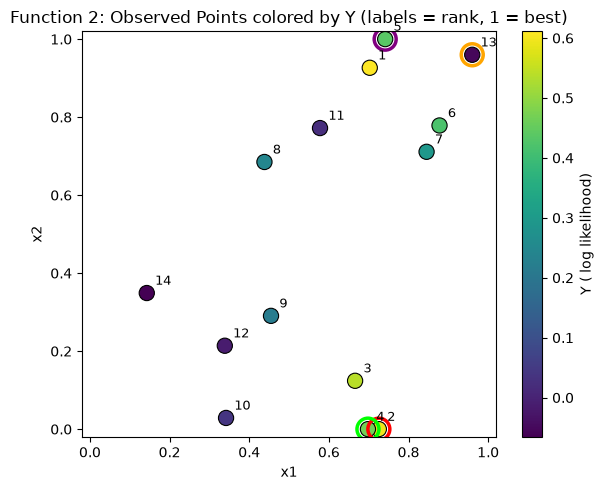

In [35]:
# Scatter Plot
fig, ax   = plt.subplots(figsize = (6,5))
sc        = ax.scatter(X[:,0], X[:,1], c = Y, cmap = 'viridis', s = 120, edgecolor = 'black', linewidth = 0.8)

# Highlighting Week 1 submitted point with a distinct marker
ax.scatter(X_w1_new_point[0], X_w1_new_point[1], facecolor = 'none', edgecolor = 'red', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 1 query')

# --- Week 2 Points ---
ax.scatter(X_w2_new_point[0], X_w2_new_point[1], facecolor = 'none', edgecolor = 'orange', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 2 query')

# --- Week 3 ---
ax.scatter(X_w3_new_point[0], X_w3_new_point[1], facecolor = 'none', edgecolor = 'lime', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 3 query')

# --- Week 4 ---
ax.scatter(X_w4_new_point[0], X_w4_new_point[1], facecolor = 'none', edgecolor = 'purple', linewidth = 2.5, s = 250, marker = 'o', label = 'Week 3 query')

ranks = (-Y).argsort().argsort() + 1
for i, (px, py) in enumerate(X):
    ax.annotate(str(ranks[i]), (px, py), textcoords = "offset points", xytext=(6, 6), fontsize = 9)
    
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title('Function 2: Observed Points colored by Y (labels = rank, 1 = best)')
fig.colorbar(sc, ax = ax, label = "Y ( log likelihood)")
plt.tight_layout()
plt.show()

**Note:** the **Week 1** query landed at x2 = 0.000000 (domain boundary), consistent with the high exploration weight (β = 2.5) used that week. Its output (y = 0.594526) is close to the current best (y = 0.611205 at rank 1), reinforcing that the region around x1 ≈ 0.7–0.9, low-to-mid x2 is promising and worth continued attention alongside the still-unexplored gaps.<br> The **Week 2** query at the opposite corner (x1 ≈ x2 ≈ 0.96) told a very different story: the GP's posterior mean there was optimistic (μ ≈ 0.39), but the true output came back at y = -0.053255, well below prediction. This is a useful information. The RBF kernel's smooth extrapolation into a far corner with no nearby observations was overconfident, and this corner should now be treated as low-value rather than promising.<br>
The **Week 3** query (x1 = 0.698058, x2 = 0.000000) landed almost on top of Week 1's point and returned y = 0.466845: a solid result, and further confirmation that the corridor around x1 ≈ 0.70–0.73, x2 ≈ 0 is a genuine, repeatable strong region. Combined with the rank-1 best sitting nearby at x1 ≈ 0.70, x2 ≈ 0.93, this raises a reasonable question worth checking in Week 4: is this one broad ridge along x1 ≈ 0.7, or are the low-x2 and high-x2 ends actually two separate peaks connected by a lower-value middle?
The **Week 4** query (x1=0.741335, x2=1.000000) landed right next to the rank-1 best point but scored **y = 0.436016**, which is noticeably lower than the rank-1 best (0.611) just 0.07 away in x2. Combined with Week 1/3's results at x2=0 (0.5–0.6), the x1≈0.7 corridor does **not** look like a flat plateau after all: output varies meaningfully across x2 even within this narrow x1 band. After 4 weeks, the best value found has not improved beyond the original data at all - this plateau, together with a reassessment of the noise level, motivated a deliberate strategy change this week.

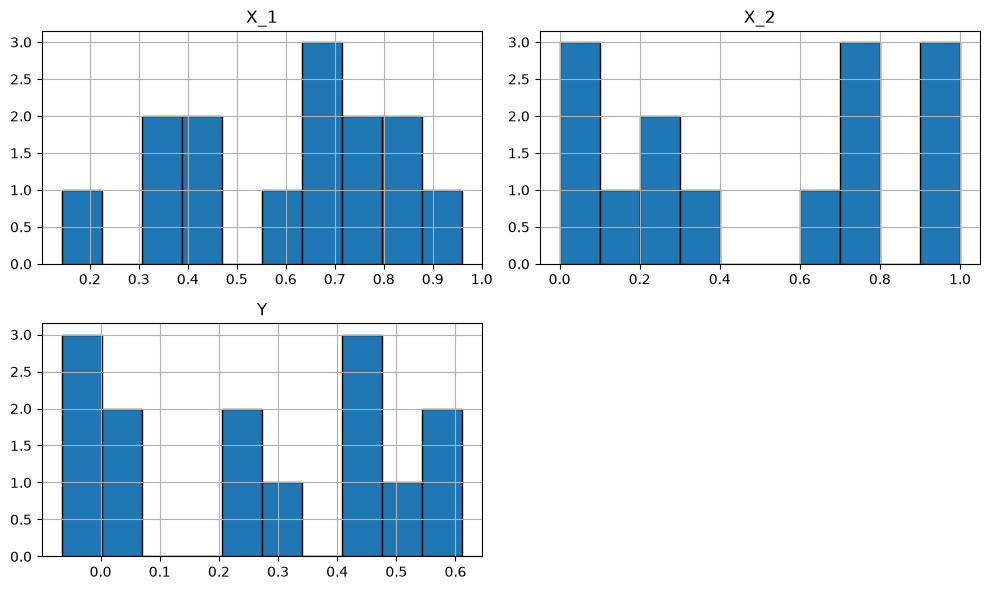

In [38]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'black' )
plt.tight_layout()
plt.show()

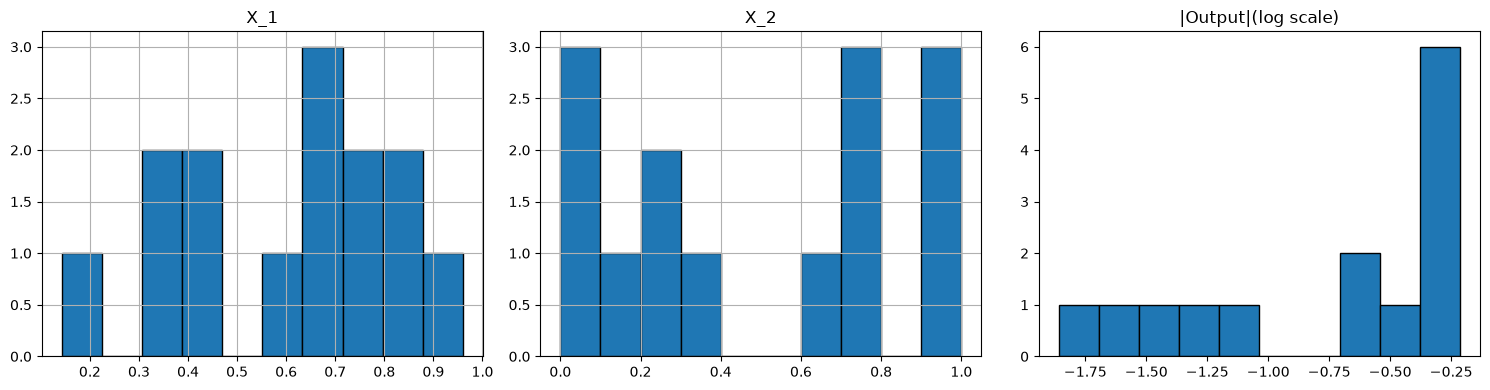

In [40]:
# In the above histogram for the output column, almost every bar seems to be crammed into a single bin near zero, which is not very informative.
# Plotting the column histograms using log scale for Output column
fig, axes = plt.subplots(1,3, figsize = (15,4))

df['X_1'].hist(ax = axes[0], bins = 10, edgecolor = 'black')
axes[0].set_title('X_1')

df['X_2'].hist(ax = axes[1], bins = 10, edgecolor = 'black')
axes[1].set_title('X_2')

magnitude = np.where(Y != 0, np.log10(np.abs(Y) + 1e-300), np.nan)
axes[2].hist(magnitude, bins = 10, edgecolor = 'black')
axes[2].set_title('|Output|(log scale)')


plt.tight_layout()
plt.show()

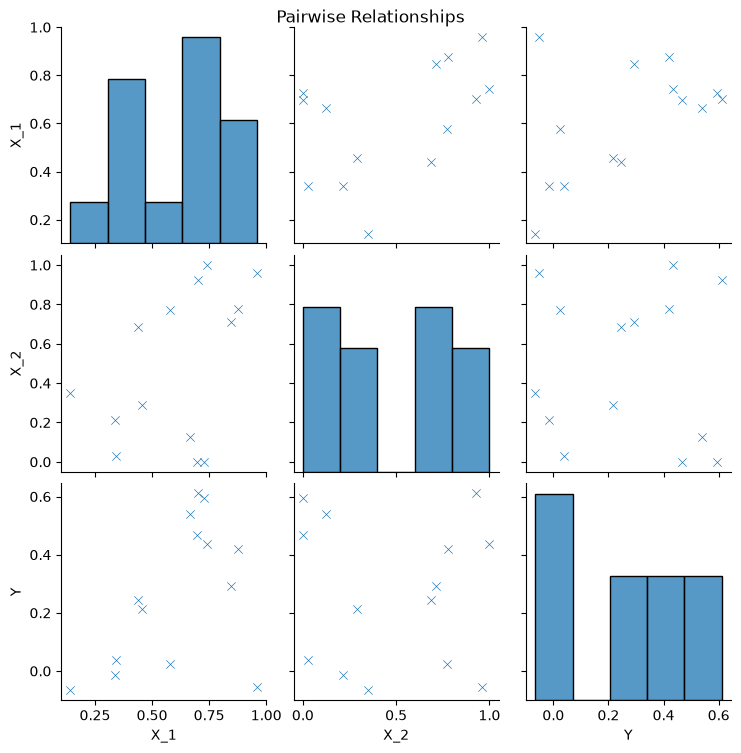

In [41]:
# Understanding the relationships between the variables using a Pair Plot
sns.pairplot(df, kind = 'scatter', diag_kind = 'hist', markers = 'x')
plt.suptitle('Pairwise Relationships', verticalalignment = 'baseline')
plt.show()

# Initialize Gaussian Process

In [45]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [48]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.881**2 * RBF(length_scale=[0.0439, 2]) + WhiteKernel(noise_level=0.0932)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- **Week 1:** uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.
- **Week 2:** β is lowered to **2.0**, to shift from exploration toward exploitation.

In [52]:
grid_res   = 500
xs         = np.linspace(0, 1, grid_res)
ys         = np.linspace(0, 1, grid_res)
gx, gy     = np.meshgrid(xs, ys)
candidates = np.column_stack([gx.ravel(), gy.ravel()])

mu, std    = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
#beta       = 2.5    #Week 1 
beta       = 2.0    #Week 2 
ucb        = mu + beta * std

best_ucb_idx = np.argmax(ucb)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.68336673 1.        ]
Predicted Mean(μ): 5.561968e-01
Predicted Std (σ): 1.040597e-01
UCB Score: 7.643162e-01


# Perform Visualisation ( Week 1 )

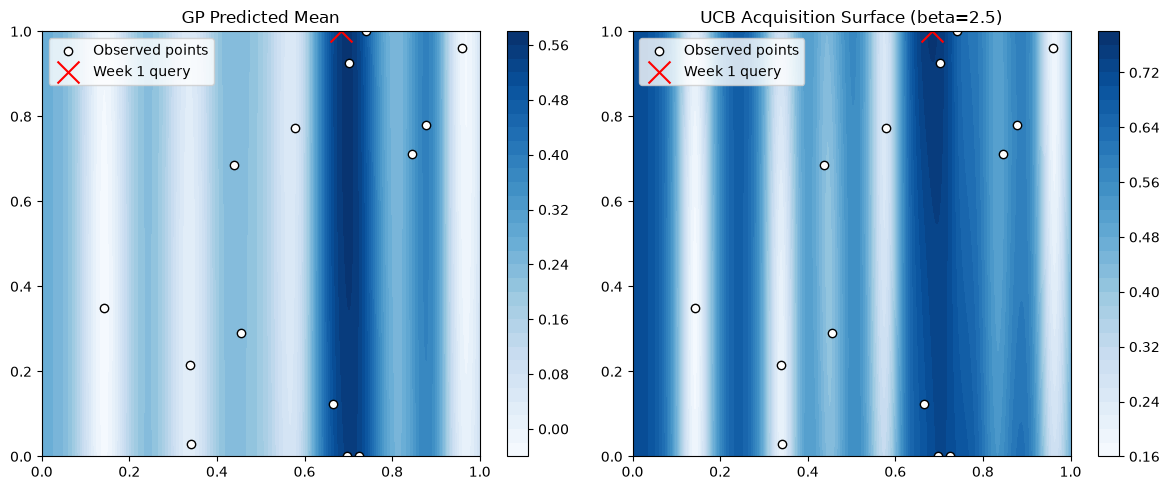

In [55]:
fig, axes  = plt.subplots(1,2, figsize = (12, 5))

# Predicted mean surface
c0 = axes[0].contourf(gx, gy, mu.reshape(gx.shape), levels = 30, cmap = "Blues")
axes[0].scatter(X[:, 0], X[:, 1], c = "white", edgecolor = "black", label = "Observed points")
axes[0].scatter(*next_point, c = "red", marker = "x", s = 250, label = "Week 1 query")
axes[0].set_title("GP Predicted Mean")
axes[0].legend(loc = 'upper left')
fig.colorbar(c0, ax=axes[0])

# UCB acquisition surface
c1 = axes[1].contourf(gx, gy, ucb.reshape(gx.shape), levels = 30, cmap = "Blues")
axes[1].scatter(X[:, 0], X[:, 1], c = "white", edgecolor = "black", label = "Observed points")
axes[1].scatter(*next_point, c = "red", marker = "x", s = 250, label = "Week 1 query")
axes[1].set_title("UCB Acquisition Surface (beta=2.5)")
axes[1].legend(loc = 'upper left')
fig.colorbar(c1, ax = axes[1])

plt.tight_layout()
plt.show()

# Week 2 Visualisation

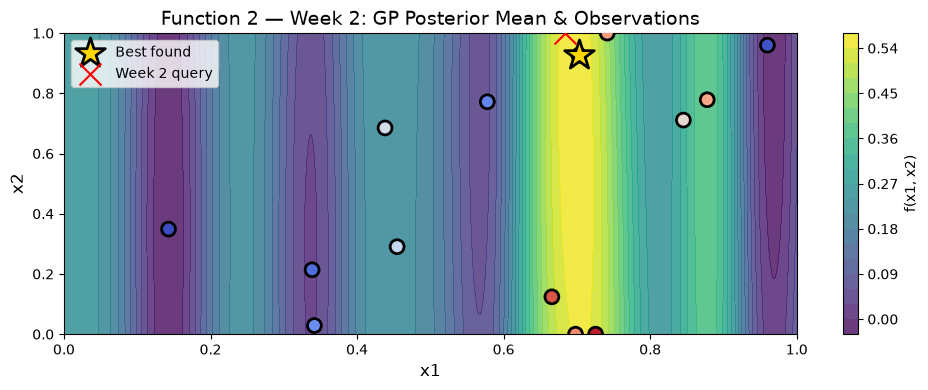

In [58]:
Z_mu = mu.reshape(gx.shape)

fig, ax = plot_2d_bo_state(gx, gy, Z_mu, X, Y, title='Function 2 \u2014 Week 2: GP Posterior Mean & Observations')
ax.scatter(*next_point, c = 'red', marker = 'x', s = 250, label = 'Week 2 query', zorder = 12)
ax.legend(loc = 'upper left')
plt.show()

# Week 3: Consolidated Bayesian Optimization Function

In [61]:
# Week 3: Consolidated Bayesian Optimization Function
def bayesian_optimization_step(X, y, bounds, beta = 2.0, kernel = None,
                                n_restarts = 20, random_state = 42):
    if kernel is None:
        kernel = (ConstantKernel(1.0, (1e-1, 1e2))
                  * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 2.0))
                  + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0)))

    gp         = GaussianProcessRegressor(kernel=kernel, normalize_y = True,
                                  n_restarts_optimizer = 10, random_state = random_state)
    gp.fit(X, y)

    def neg_ucb(x):
        x         = np.array(x).reshape(1, -1)
        mu, sigma = gp.predict(x, return_std = True)
        return -(mu[0] + beta * sigma[0])

    lows          = [b[0] for b in bounds]
    highs         = [b[1] for b in bounds]

    best_val      = np.inf
    best_x        = None
    rng           = np.random.default_rng(random_state)
    for _ in range(n_restarts):
        x0        = rng.uniform(lows, highs)
        result    = minimize(neg_ucb, x0, bounds = bounds, method = 'L-BFGS-B')
        if result.fun < best_val:
            best_val = result.fun
            best_x   = result.x

    mu_next, std_next = gp.predict(best_x.reshape(1, -1), return_std = True)

    return {
        'gp': gp,
        'next_point': best_x,
        'mu': mu_next[0],
        'std': std_next[0],
        'ucb': -best_val,
    }

In [63]:
# Run the consolidated function for Week 3
# lowered value of beta from Week 2's 2.0 to 1.5
beta             = 1.5   
bounds_2d        = [(0.0, 1.0), (0.0, 1.0)]

result_week3     = bayesian_optimization_step(X, Y, bounds_2d, beta = beta)

next_point_week3 = result_week3['next_point']

print(f"Suggested Week 3 Query Point: {next_point_week3}")
print(f"Predicted Mean(\u03bc): {result_week3['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week3['std']:.6e}")
print(f"UCB Score: {result_week3['ucb']:.6e}")


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 3 Query Point: [0.68838957 1.        ]
Predicted Mean(μ): 5.618816e-01
Predicted Std (σ): 1.008835e-01
UCB Score: 7.132069e-01


# Week 3 Visualisation

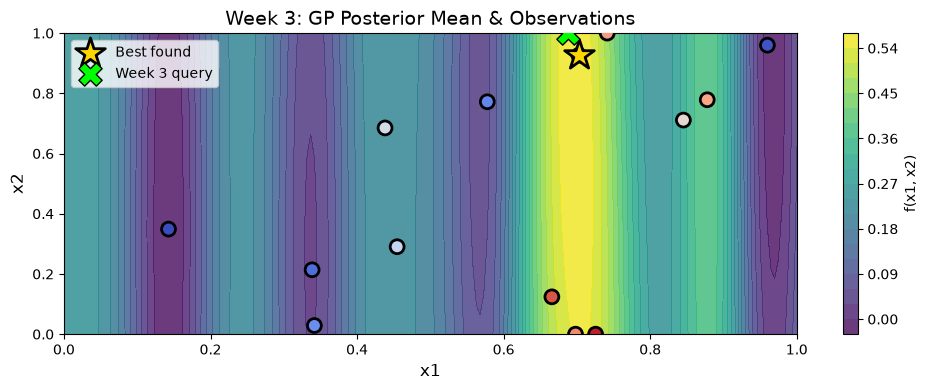

In [66]:
grid_res_w3   = 200
xs_w3         = np.linspace(0, 1, grid_res_w3)
ys_w3 = np.linspace(0, 1, grid_res_w3)
gx_w3, gy_w3  = np.meshgrid(xs_w3, ys_w3)
grid_w3       = np.column_stack([gx_w3.ravel(), gy_w3.ravel()])

mu_grid_w3, _ = result_week3['gp'].predict(grid_w3, return_std = True)
Z_mu_w3       = mu_grid_w3.reshape(gx_w3.shape)

fig, ax       = plot_2d_bo_state(gx_w3, gy_w3, Z_mu_w3, X, Y,
                            title = 'Week 3: GP Posterior Mean & Observations')
ax.scatter(*next_point_week3, c = 'lime', marker = 'X', s = 280,
           edgecolor = 'black', label = 'Week 3 query', zorder = 12)
ax.legend(loc = 'upper left')
plt.show()

# Week 4: Compare Candidate Peak Regions Found So Far

Before querying again, it's worth checking whether the top-performing points found so far cluster into one region or several. This directly informs whether Week 4 should exploit one area or continue probing for a second optimum.

In [69]:
top_k        = 4
top_idx      = np.argsort(-Y)[:top_k]

print(f"Top {top_k} points by output value:\n")
for rank, i in enumerate(top_idx, start=1):
    print(f"  Rank {rank}: x = ({X[i,0]:.4f}, {X[i,1]:.4f}), y = {Y[i]:.4f}")

# Pairwise distance between the top points, to check if they're clustered
# (one region) or spread apart (possible separate local optima)
from scipy.spatial.distance import pdist, squareform
top_X       = X[top_idx]
dist_matrix = squareform(pdist(top_X))
print("\nPairwise distances among top points:\n", np.round(dist_matrix, 3))

max_dist    = dist_matrix.max()
print(f"\nMax distance among top {top_k} points: {max_dist:.3f}")
if max_dist > 0.5:
    print("Top points are spread apart => consistent with more than one promising region.")
else:
    print("Top points are relatively close together => consistent with a single broad region.")

Top 4 points by output value:

  Rank 1: x = (0.7026, 0.9266), y = 0.6112
  Rank 2: x = (0.7255, 0.0000), y = 0.5945
  Rank 3: x = (0.6658, 0.1240), y = 0.5390
  Rank 4: x = (0.6981, 0.0000), y = 0.4668

Pairwise distances among top points:
 [[0.    0.927 0.803 0.927]
 [0.927 0.    0.138 0.027]
 [0.803 0.138 0.    0.128]
 [0.927 0.027 0.128 0.   ]]

Max distance among top 4 points: 0.927
Top points are spread apart => consistent with more than one promising region.


# Week 4: Kernel Re-tuning Check
Across Weeks 1–3, the fitted RBF kernel's x2 length-scale has repeatedly settled at or near its upper bound (2.0), triggering a scikit-learn convergence warning each time. This can mean the model wants an even larger length-scale than allowed (i.e., it thinks the function is smoother/flatter along x2 than the bound permits). Worth checking directly rather than ignoring the warning again this week.

In [72]:
# Original kernel (bounds used since Week 1): length_scale_bounds = (1e-2, 2.0)
log_ml_original  = gpr.log_marginal_likelihood(gpr.kernel_.theta)
print(f"Original kernel:              {gpr.kernel_}")
print(f"Log-marginal-likelihood:      {log_ml_original:.4f}")

# Widened-bounds candidate: let the length-scale optimiser search further,
# in case the true optimum lies beyond the original 2.0 cap
kernel_rbf_wide  = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale = [0.25, 0.25], length_scale_bounds = (1e-2, 5.0)) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_wide = GaussianProcessRegressor(kernel = kernel_rbf_wide, normalize_y = True,
                                     n_restarts_optimizer = 10, random_state = 42)
gpr_wide.fit(X, Y)
log_ml_wide      = gpr_wide.log_marginal_likelihood(gpr_wide.kernel_.theta)
print(f"\nWidened-bounds kernel:        {gpr_wide.kernel_}")
print(f"Log-marginal-likelihood:      {log_ml_wide:.4f}")

# Adopt whichever kernel fits better (higher log-marginal-likelihood)
if log_ml_wide > log_ml_original:
    print("\n-> Widened-bounds kernel fits better; using it for Week 4's acquisition step.")
    kernel_week4 = gpr_wide.kernel_
else:
    print("\n-> Original kernel bounds were already adequate; keeping them for Week 4.")
    kernel_week4 = gpr.kernel_

Original kernel:              0.881**2 * RBF(length_scale=[0.0439, 2]) + WhiteKernel(noise_level=0.0932)
Log-marginal-likelihood:      -15.4547

Widened-bounds kernel:        0.904**2 * RBF(length_scale=[0.0467, 5]) + WhiteKernel(noise_level=0.0942)
Log-marginal-likelihood:      -15.1377

-> Widened-bounds kernel fits better; using it for Week 4's acquisition step.


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Week 4: Running the Consolidated Function with the Re-tuned Kernel

In [73]:
beta_week4       = 1.2   # lowered from Week 3's 1.5
bounds_2d        = [(0.0, 1.0), (0.0, 1.0)]

result_week4     = bayesian_optimization_step(X, Y, bounds_2d, beta = beta_week4, kernel = kernel_week4)

next_point_week4 = result_week4['next_point']

print(f"Suggested Week 4 Query Point: {next_point_week4}")
print(f"Predicted Mean(\u03bc): {result_week4['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week4['std']:.6e}")
print(f"UCB Score: {result_week4['ucb']:.6e}")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 4 Query Point: [0.74133539 1.        ]
Predicted Mean(μ): 5.479308e-01
Predicted Std (σ): 1.197992e-01
UCB Score: 6.916898e-01


# Week 4: Visualisation

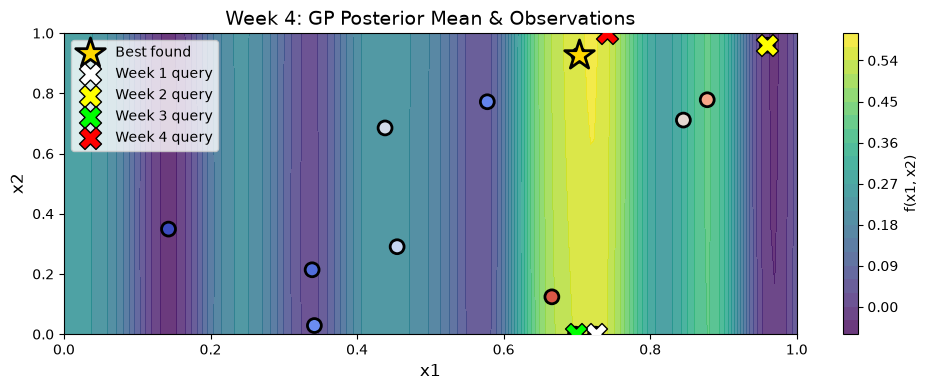

In [87]:
grid_res_w4   = 200
xs_w4         = np.linspace(0, 1, grid_res_w4)
ys_w4         = np.linspace(0, 1, grid_res_w4)
gx_w4, gy_w4  = np.meshgrid(xs_w4, ys_w4)
grid_w4       = np.column_stack([gx_w4.ravel(), gy_w4.ravel()])

mu_grid_w4, _ = result_week4['gp'].predict(grid_w4, return_std=True)
Z_mu_w4       = mu_grid_w4.reshape(gx_w4.shape)

fig, ax       = plot_2d_bo_state(gx_w4, gy_w4, Z_mu_w4, X, Y,
                            title='Week 4: GP Posterior Mean & Observations')
ax.scatter(*X_w1_new_point, c = 'white' , marker = 'X', s = 250, edgecolor ='black', label='Week 1 query', zorder = 12)
ax.scatter(*X_w2_new_point, c = 'yellow', marker = 'X', s = 250, edgecolor ='black', label='Week 2 query', zorder = 12)
ax.scatter(*X_w3_new_point, c = 'lime'  , marker = 'X', s = 250, edgecolor ='black', label='Week 3 query', zorder = 12)

ax.scatter(*next_point_week4, c = 'red' , marker = 'X', s = 250, edgecolor ='black', label='Week 4 query', zorder = 12)

ax.legend(loc = 'upper left')
plt.show()

# Week 5: Comparing noise level with incremental data

In [78]:
snapshots = [
    ('After initial 10 pts',  X_updated[:10],  Y_updated[:10]),
    ('After Week 1 (11 pts)', X_updated[:11],  Y_updated[:11]),
    ('After Week 3 (13 pts)', X_updated[:13],  Y_updated[:13]),
    ('After Week 4 (14 pts)', X_updated[:14],  Y_updated[:14]),
]
for label, Xs, Ys in snapshots:
    k = ConstantKernel(1.0, (1e-1, 1e2)) * RBF(length_scale=[0.25, 0.25], length_scale_bounds=(1e-2, 2.0)) \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e0))
    g = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=10, random_state=42)
    g.fit(Xs, Ys)
    noise = g.kernel_.k2.noise_level
    print(f"{label}: fitted noise_level = {noise:.4f}")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


After initial 10 pts: fitted noise_level = 0.0148


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


After Week 1 (11 pts): fitted noise_level = 0.0125


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


After Week 3 (13 pts): fitted noise_level = 0.0364
After Week 4 (14 pts): fitted noise_level = 0.0932


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


**Note:** Noise estimates have grown substantially as more data arrived.

# Week 5: Checking for under-sampled regions

In [89]:
grid_res_gap = 200
xs_gap = np.linspace(0, 1, grid_res_gap)
ys_gap = np.linspace(0, 1, grid_res_gap)
gx_gap, gy_gap = np.meshgrid(xs_gap, ys_gap)
grid_gap = np.column_stack([gx_gap.ravel(), gy_gap.ravel()])

from scipy.spatial.distance import cdist
dists_gap = cdist(grid_gap, X_updated)
min_dist_gap = dists_gap.min(axis=1)

quadrants = {
    'low x1, low x2':   (grid_gap[:, 0] < 0.5) & (grid_gap[:, 1] < 0.5),
    'low x1, high x2':  (grid_gap[:, 0] < 0.5) & (grid_gap[:, 1] >= 0.5),
    'high x1, low x2':  (grid_gap[:, 0] >= 0.5) & (grid_gap[:, 1] < 0.5),
    'high x1, high x2': (grid_gap[:, 0] >= 0.5) & (grid_gap[:, 1] >= 0.5),
}
print("Average distance to nearest observed point, by quadrant:\n")
for name, mask in quadrants.items():
    print(f"  {name:20s}: {min_dist_gap[mask].mean():.4f}")


Average distance to nearest observed point, by quadrant:

  low x1, low x2      : 0.1227
  low x1, high x2     : 0.2406
  high x1, low x2     : 0.1890
  high x1, high x2    : 0.1075


**Observation:** Low x1, High x2 is a clear gap. Almost entirely unsampled so far.
**Decision   :** Above checks all point the same direction - a rising noise estimate that weakens confidence in the corridor's apparent edge, and a large, genuinely under-sampled region (low x1, high x2) that hasn't been tested at all. This is a reasonable basis to **change strategy in week 5**. Rather than continuing to lower β and refine around the same corridor, β is raised back up (1.2 to 1.8) and this week's search is deliberately pointed at the under-sampled quadrant, to check whether a second, better optimum exists there before committing to further local refinement.

One more check before committing to this: does the *default* global acquisition search even still want to revisit the same corridor, or has it already started drifting toward new ground on its own?

In [95]:
probe_result = bayesian_optimization_step(X_updated, Y_updated, [(0.0, 1.0), (0.0, 1.0)],
                                           beta=1.8, kernel=kernel_week4)
probe_point = probe_result['next_point']
dist_to_week4 = np.linalg.norm(probe_point - X_w4_new_point)

print(f"Naive global suggestion (beta=1.8): {probe_point}")
print(f"Distance to Week 4's already-submitted point: {dist_to_week4:.4f}")
if dist_to_week4 < 0.1:
    print("Nearly a repeat of Week 4's query(low marginal information). Overriding with a deliberately restricted search of the under-sampled quadrant instead.")

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Naive global suggestion (beta=1.8): [0.6959604 1.       ]
Distance to Week 4's already-submitted point: 0.0454
Nearly a repeat of Week 4's query(low marginal information). Overriding with a deliberately restricted search of the under-sampled quadrant instead.


# Week 5: Querying the under-sampled quadrant

In [100]:
beta_week5 = 1.8   # raised from Week 4's 1.2 -- deliberate strategy reversal
bounds_quadrant = [(0.05, 0.45), (0.55, 0.95)]   # under-sampled region, inset from domain edges

result_week5 = bayesian_optimization_step(X_updated, Y_updated, bounds_quadrant,
                                           beta=beta_week5, kernel=kernel_week4)

next_point_week5 = result_week5['next_point']

print(f"Suggested Week 5 Query Point: {next_point_week5}")
print(f"Predicted Mean(\u03bc): {result_week5['mu']:.6e}")
print(f"Predicted Std (\u03c3): {result_week5['std']:.6e}")
print(f"UCB Score: {result_week5['ucb']:.6e}")
print()

C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Suggested Week 5 Query Point: [0.05 0.95]
Predicted Mean(μ): 2.263560e-01
Predicted Std (σ): 2.263032e-01
UCB Score: 6.337018e-01



# Week 5: Visualisation

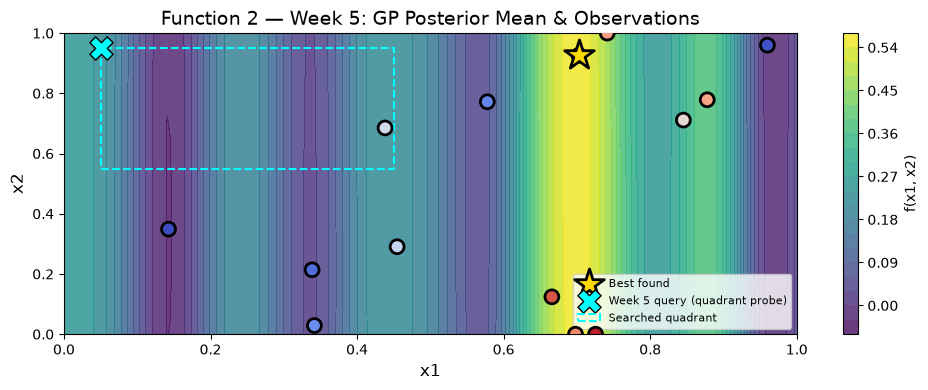

In [105]:
grid_res_w5 = 200
xs_w5 = np.linspace(0, 1, grid_res_w5)
ys_w5 = np.linspace(0, 1, grid_res_w5)
gx_w5, gy_w5 = np.meshgrid(xs_w5, ys_w5)
grid_w5 = np.column_stack([gx_w5.ravel(), gy_w5.ravel()])

mu_grid_w5, _ = result_week5['gp'].predict(grid_w5, return_std=True)
Z_mu_w5 = mu_grid_w5.reshape(gx_w5.shape)

fig, ax = plot_2d_bo_state(gx_w5, gy_w5, Z_mu_w5, X_updated, Y_updated,
                            title='Function 2 \u2014 Week 5: GP Posterior Mean & Observations')
ax.scatter(*next_point_week5, c='cyan', marker='X', s=280,
           edgecolor='black', label='Week 5 query (quadrant probe)', zorder=12)

import matplotlib.patches as patches
rect = patches.Rectangle((0.05, 0.55), 0.40, 0.40, linewidth=1.5, edgecolor='cyan',
                          facecolor='none', linestyle='--', label='Searched quadrant')
ax.add_patch(rect)
ax.legend(loc='lower right', fontsize=8)
plt.show()

# Portal Submission 

In [109]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point_week5[0]:.6f}-{next_point_week5[1]:.6f}"
print("Points to be submitted (Week 1):", '0.725451-0.000000')
print("Points to be submitted (Week 2):", '0.959920-0.959920')
print("Points to be submitted (Week 3):", '0.698058-0.000000')
print("Points to be submitted (Week 4):", '0.741335-1.000000')
print("Points to be submitted (Week 5):", submission_str)
print()

Points to be submitted (Week 1): 0.725451-0.000000
Points to be submitted (Week 2): 0.959920-0.959920
Points to be submitted (Week 3): 0.698058-0.000000
Points to be submitted (Week 4): 0.741335-1.000000
Points to be submitted (Week 5): 0.050000-0.950000



# Plot the Progress of the optimisation process

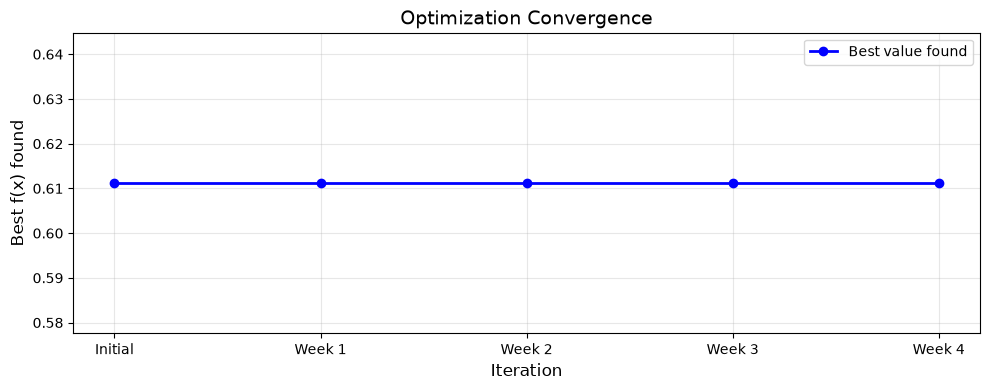

Best value found so far: 0.6112052157614438


In [112]:
# Track best-value-found progress across weeks
best_so_far = [
    0.6112052157614438,                              # best after initial 10 points
    max(0.6112052157614438, 0.594525526714632),      # best after Week 1
    max(0.6112052157614438, -0.053254980810696906),  # best after Week 2
    max(0.6112052157614438, 0.46684490847445986),    # best after Week 3
    max(0.6112052157614438, 0.4360156328364332),     # best after Week 4
]

fig, ax     = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(['Initial', 'Week 1', 'Week 2', 'Week 3', 'Week 4'])
plt.show()

print("Best value found so far:", max(best_so_far))